# Introduction to LLMs and Building a Simple LLM Agent

This notebook has two goals:

1. Introduce the core ideas behind **large language models (LLMs)**
2. Walk through a **minimal agent implementation** you can run and extend

The notebook is designed to be beginner-friendly, but the agent example is structured in a way that maps to real production systems.

## What is an LLM?

A **large language model** is a neural network trained on huge amounts of text to predict the next token in a sequence.

In practice, that means an LLM can:
- answer questions
- summarize content
- write code
- extract structured data
- reason through multi-step tasks
- decide when to use external tools

### Key ideas

**Tokens**  
Models do not see raw text the way humans do. They process text as token sequences.

**Context window**  
The model can only consider a limited amount of input at once.

**Inference**  
When you send a prompt to a model, it generates a continuation token by token.

**Training vs. prompting**  
You usually do **not** retrain a model for every task. Instead, you guide it using:
- system instructions
- user prompts
- examples
- tools
- retrieved knowledge

In [1]:
text = "LLMs are powerful because they can model patterns in language."
tokens = text.split()  # toy example, real tokenization is more complex

print("Text:")
print(text)
print("\nToy tokens:")
print(tokens)
print("\nToken count:", len(tokens))

Text:
LLMs are powerful because they can model patterns in language.

Toy tokens:
['LLMs', 'are', 'powerful', 'because', 'they', 'can', 'model', 'patterns', 'in', 'language.']

Token count: 10


## Why LLMs feel intelligent

LLMs often appear intelligent because they can compress and recombine patterns learned from data.

But they also have limitations:
- they can hallucinate
- they can make arithmetic mistakes
- they may miss recent facts
- they do not inherently know when they are uncertain

This is why real applications often combine LLMs with:
- **tools** (calculator, search, database calls, APIs)
- **retrieval** (RAG)
- **validation**
- **memory/state**
- **guardrails**

## LLM API Provider


Google AI Studio: https://aistudio.google.com/

We need to create an API key: https://aistudio.google.com/api-keys?project=gen-lang-client-0182142589

In [ ]:
!pip install google-generativeai

In [2]:
import google.generativeai as genai

genai.configure(api_key="")

In [3]:
for m in genai.list_models():
    methods = getattr(m, "supported_generation_methods", [])
    if "generateContent" in methods:
        print(m.name, methods)

models/gemini-2.5-flash ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-pro ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-001 ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite-001 ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.0-flash-lite ['generateContent', 'countTokens', 'createCachedContent', 'batchGenerateContent']
models/gemini-2.5-flash-preview-tts ['countTokens', 'generateContent']
models/gemini-2.5-pro-preview-tts ['countTokens', 'generateContent', 'batchGenerateContent']
models/gemma-3-1b-it ['generateContent', 'countTokens']
models/gemma-3-4b-it ['generateContent', 'countTokens']
models/gemma-3-12b-it ['generateContent', 'countTokens']
models/gemma-3-

## LLM Call

In [7]:
# Use a safe model name (update if needed)
MODEL_NAME = "gemma-3-1b-it"

model = genai.GenerativeModel(MODEL_NAME)

response = model.generate_content("Can you elabrate more on this?")
print(response.text)

Please provide me with the "this" you're referring to! I need the text, topic, or situation you want me to elaborate on. 😊 

I’m here to help, but I need something to work with. 😊 

Just paste the text, describe the topic, or tell me what you’re curious about – and I’ll do my best to elaborate!


## Prompt Engineering Basics

In [8]:
prompt = """
Explain Newton's second law.

Then give:
1. A simple explanation
2. A real-world example
3. The formula
"""

response = model.generate_content(prompt)
print(response.text)

Okay, let's break down Newton's Second Law of Motion.

**1. A Simple Explanation**

Newton's Second Law basically says this: **The force you apply to an object is directly related to the object's mass and the acceleration it experiences.**

Think of it like this:

* **Force (F):**  A push or a pull. It's what makes something move or stop.
* **Mass (m):** How much "stuff" is in an object.  More mass means more inertia (resistance to change in motion).
* **Acceleration (a):** How quickly the object is changing its speed or direction.

**The Law Says:**  If you increase the force you apply, the object will accelerate faster. If you decrease the force, the object will accelerate slower.  If you keep the force the same, the object will accelerate at a constant rate.

**2. Real-World Example**

Let's say you're pushing a shopping cart.

* **Force:** You apply a force to push the cart.
* **Mass:** The shopping cart has a certain amount of mass (let's say 10 kg).
* **Acceleration:**  As you pu

## Role prompting 

In [9]:
prompt = """
You are a funny teacher.

Explain what a neural network is.
"""

response = model.generate_content(prompt)
print(response.text)

Alright everyone, settle down, settle down! Let’s talk about something seriously cool… and slightly terrifying. We’re going to talk about Neural Networks! 

(I pause dramatically, adjusting my glasses)

Now, I know what you’re thinking: “Neural Networks? Sounds like something a robot will do!” And you’re not *completely* wrong. But trust me, they’re actually incredibly clever little brains. 

Think of it like this: your brain is amazing. It learns things, remembers things, and makes decisions. But it’s not a *perfect* brain. It’s messy, it’s prone to mistakes, and it sometimes just… *guesses*. 

A Neural Network is basically a computer program that tries to mimic that messy, imperfect brain. 

**(I gesture wildly with my hands)**

Let’s break it down with a silly analogy: Imagine you’re teaching a puppy to recognize a ball. 

* **You show the puppy *lots* of balls:** You throw a tennis ball, you say “ball!”  The puppy starts to associate the ball with being a ball.
* **The puppy *makes

In [10]:
prompt = """
You are a concise teacher.

Explain what a neural network is.
"""

response = model.generate_content(prompt)
print(response.text)

Okay, here’s a concise explanation of neural networks:

**Imagine a network of interconnected nodes (like brain cells) that learn to recognize patterns.**

*   **Input:** You feed the network data – like images, text, or numbers.
*   **Layers:** These nodes are organized into layers:
    *   **Input Layer:** Receives the raw data.
    *   **Hidden Layers:**  Perform complex calculations and feature extraction.  There can be many.
    *   **Output Layer:** Produces the final result (e.g., "cat" or "spam").
*   **Connections:**  Nodes are connected, and each connection has a "weight" – a number that determines how important that connection is.
*   **Learning:** The network adjusts these weights through a process called "training," using lots of examples. It gets better and better at making predictions.

**In short: A neural network is a computer program that learns to recognize patterns by mimicking the way the human brain works.**

---

Do you want me to explain a specific aspect in mor

## Reasoning example

In [11]:
prompt = "If I have 3 apples and buy 4 more, how many apples do I have?"

response = model.generate_content(prompt)
print(response.text)

You have 7 apples.

3 + 4 = 7



## Structured output (IMPORTANT for your agent)

In [12]:
prompt = """
Return ONLY JSON.

Question: What is 2 + 2?

Format:
{
  "result": number
}
"""

response = model.generate_content(prompt)
print(response.text)

```json
{
  "result": 4
}
```



## Function-calling mindset (pre-agent)

In [14]:
prompt = """
You are an AI that decides whether to use a calculator.

User: What is 45 * 12?

Return JSON:
{
  "use_tool": true/false,
  "tool": "calculator",
  "input": "..."
  "outpu": "result"
}
"""

response = model.generate_content(prompt)
print(response.text)

```json
{
  "use_tool": true,
  "tool": "calculator",
  "input": "45 * 12",
  "outpu": "540"
}
```


In [15]:
def debug_llm(prompt):
    print("PROMPT:\n", prompt)
    print("\n---\n")
    response = model.generate_content(prompt)
    print("RESPONSE:\n", response.text)
    return response.text

In [16]:
debug_llm("If I have 3 apples and buy 4 more, how many apples do I have?")

PROMPT:
 If I have 3 apples and buy 4 more, how many apples do I have?

---

RESPONSE:
 You have 7 apples.

3 + 4 = 7



'You have 7 apples.\n\n3 + 4 = 7\n'

## From chatbots to agents

A plain chatbot mostly does:

> input text → model → output text

An **agent** adds an action loop:

1. Observe the user request
2. Decide what to do next
3. Optionally call a tool
4. Incorporate the tool result
5. Continue until it can answer

A simple mental model is:

> LLM = reasoning engine  
> Tools = ways to act on the outside world  
> Agent loop = glue code that orchestrates everything

# Rule based agent (no LLM)

## Agent architecture we will build

We will create a tiny agent with:
- a small set of tools
- a planner step
- a tool execution step
- a final answer step


In [21]:
from dataclasses import dataclass, field  # Used to create simple data classes with less boilerplate
from typing import Any, Dict, List, Callable  # Type hints for better readability and tooling
import json  # For working with JSON data (often used in LLM outputs)
import math  # Math utilities (can be used as a tool)
from datetime import datetime  # For time-related tools


# -----------------------------
# Tool definition
# -----------------------------
@dataclass
class Tool:
    # Name of the tool (used by the agent to reference it)
    name: str
    
    # Description of what the tool does (helps the LLM decide when to use it)
    description: str
    
    # The actual function the tool runs
    # Callable[..., Any] means: a function with any arguments returning anything
    fn: Callable[..., Any]



In [22]:
# -----------------------------
# Agent state (memory)
# -----------------------------
@dataclass
class AgentState:
    # Stores conversation history
    # Each item is a dictionary like:
    # {"role": "user", "content": "Hello"}
    messages: List[Dict[str, str]] = field(default_factory=list)
    
    # Stores internal reasoning steps / intermediate thoughts
    # This is NOT shown to the user, only used by the agent internally
    scratchpad: List[str] = field(default_factory=list)

## Step 1: Define a few tools

We will give the agent two tools:
- a calculator
- a clock

In production, these could be replaced with:
- web search
- CRM lookups
- SQL queries
- document retrieval
- code execution

In [17]:
# -----------------------------
# Calculator tool
# -----------------------------
def calculator(expression: str) -> str:
    # Define which functions are allowed inside eval (for safety)
    # This prevents users from executing dangerous code
    allowed_names = {
        "abs": abs,          # absolute value
        "round": round,      # rounding numbers
        "min": min,          # minimum of values
        "max": max,          # maximum of values
        "pow": pow,          # power function
        "sqrt": math.sqrt,   # square root from math module
    }

    try:
        # Evaluate the expression safely:
        # - Disable all built-ins (__builtins__ = {})
        # - Only allow the functions defined above
        result = eval(expression, {"__builtins__": {}}, allowed_names)

        # Convert result to string (LLMs usually expect strings)
        return str(result)

    except Exception as e:
        # If something goes wrong (bad syntax, etc.), return an error message
        return f"Calculator error: {e}"

In [18]:
# -----------------------------
# Current time tool
# -----------------------------
def current_time() -> str:
    # Get current local date and time
    now = datetime.now()

    # Format it as a readable string: YYYY-MM-DD HH:MM:SS
    return now.strftime("%Y-%m-%d %H:%M:%S")

In [23]:
# -----------------------------
# Tool registry (what the agent can use)
# -----------------------------
tools = {
    "calculator": Tool(
        name="calculator",  # Tool name used by the agent
        description="Evaluate a basic Python-style math expression, e.g. '23 * (7 + 1)'",
        fn=calculator,     # Function the tool executes
    ),
    "current_time": Tool(
        name="current_time",
        description="Return the current local date and time",
        
        # Wrap the function in a lambda so it can be called uniformly
        # (useful if tools later expect arguments)
        fn=lambda: current_time(),
    ),
}


In [24]:
# -----------------------------
# Debug / display available tools
# -----------------------------
for tool in tools.values():
    # Print each tool's name and description
    # This helps verify what the agent has access to
    print(f"{tool.name}: {tool.description}")

calculator: Evaluate a basic Python-style math expression, e.g. '23 * (7 + 1)'
current_time: Return the current local date and time


## Step 2: Create a planner

A real agent usually lets the LLM decide:
- whether to answer immediately
- whether to call a tool
- which tool to call
- what arguments to use

For this notebook, we will simulate that behavior with a simple rule-based planner first, so the full loop is easy to inspect.

In [25]:
def simple_plan(user_query: str) -> Dict[str, Any]:
    # Convert user input to lowercase for easier matching
    q = user_query.lower()

    # -----------------------------
    # Check if the user is asking about time/date
    # -----------------------------
    # If any of these keywords appear, use the time tool
    if any(word in q for word in ["time", "date", "clock"]):
        return {
            "type": "tool_call",        # Indicates the agent should call a tool
            "tool_name": "current_time",# Which tool to call
            "tool_args": {}             # No arguments needed for this tool
        }

    # -----------------------------
    # Check if the user is asking for a math calculation
    # -----------------------------
    # Look for common math-related symbols or phrases
    math_markers = ["+", "-", "*", "/", "sqrt", "(", ")", "calculate", "what is"]

    if any(marker in q for marker in math_markers):
        # Clean up the query to extract just the math expression
        # Example: "what is 2 + 2" → "2 + 2"
        expression = (
            user_query.lower()
            .replace("calculate", "")   # Remove keyword
            .replace("what is", "")     # Remove keyword
            .strip()                    # Remove extra spaces
        )

        return {
            "type": "tool_call",        # Agent should call a tool
            "tool_name": "calculator",  # Use calculator tool
            "tool_args": {
                "expression": expression  # Pass extracted math expression
            }
        }

    # -----------------------------
    # Default: no tool needed
    # -----------------------------
    # If it's not time or math, just answer directly
    return {
        "type": "final_answer",  # No tool call, just respond
        "content": "I can answer directly: " + user_query
    }

## Step 3: Build the agent loop

This loop:
1. receives the user request
2. creates a plan
3. optionally runs a tool
4. returns a final response

Even though this example is small, it mirrors the structure of many real-world agent systems.

In [26]:
def run_agent(user_query: str, tools: Dict[str, Tool]) -> str:
    # -----------------------------
    # Initialize agent state (memory)
    # -----------------------------
    # Store the user's message as the first entry in conversation history
    state = AgentState(messages=[{"role": "user", "content": user_query}])

    # -----------------------------
    # PLAN step (decide what to do)
    # -----------------------------
    # Use the simple planner to determine next action
    plan = simple_plan(user_query)

    # Save the plan in the scratchpad (internal reasoning log)
    state.scratchpad.append(f"Plan: {json.dumps(plan)}")

    # -----------------------------
    # ACT step (execute tool if needed)
    # -----------------------------
    if plan["type"] == "tool_call":
        tool_name = plan["tool_name"]   # Which tool to use
        tool_args = plan["tool_args"]   # Arguments for the tool

        # Safety check: make sure the tool exists
        if tool_name not in tools:
            return f"Unknown tool requested: {tool_name}"

        # Call the tool function with provided arguments
        # Example: calculator(expression="2+2")
        tool_result = tools[tool_name].fn(**tool_args)

        # Log the result in the scratchpad
        state.scratchpad.append(f"Tool result from {tool_name}: {tool_result}")

        # -----------------------------
        # OBSERVE + RESPOND step
        # -----------------------------
        # Return a structured explanation of what happened
        return (
            f"User asked: {user_query}\n"
            f"Agent decided to call tool: {tool_name}\n"
            f"Tool result: {tool_result}\n"
            f"Final answer: Based on the tool result, the answer is {tool_result}"
        )

    # -----------------------------
    # If no tool is needed
    # -----------------------------
    # Just return the direct response from the planner
    return plan["content"]

In [27]:
examples = [
    "What time is it?",
    "Calculate 19 * (7 + 3)",
    "Explain what an LLM is in one sentence.",
]

for q in examples:
    print("=" * 80)
    print(run_agent(q, tools))

User asked: What time is it?
Agent decided to call tool: current_time
Tool result: 2026-04-08 20:34:54
Final answer: Based on the tool result, the answer is 2026-04-08 20:34:54
User asked: Calculate 19 * (7 + 3)
Agent decided to call tool: calculator
Tool result: 190
Final answer: Based on the tool result, the answer is 190
I can answer directly: Explain what an LLM is in one sentence.


## What makes this an agent?

This example qualifies as an agent because it has:
- **state**
- **decision-making**
- **tool use**
- **multi-step execution**

It is still minimal, but the core pattern is already there.

## Upgrading from rule-based planning to an LLM-based planner

In a production system, the `simple_plan(...)` function would usually be replaced with an LLM call.

The model would return a structured plan such as:

```json
{
  "type": "tool_call",
  "tool_name": "calculator",
  "tool_args": {"expression": "19 * (7 + 3)"}
}
```

That structured output can then be validated and executed by your Python code.

In [28]:
SYSTEM_PROMPT = '''
You are an agent planner.
Given a user request, return JSON with exactly one of these forms:

1) Tool call:
{"type": "tool_call", "tool_name": "<name>", "tool_args": {...}}

2) Final answer:
{"type": "final_answer", "content": "<answer>"}

Available tools:
- calculator: Evaluate a basic math expression
- current_time: Return the current local date and time

Return JSON only.
'''.strip()

print(SYSTEM_PROMPT)

You are an agent planner.
Given a user request, return JSON with exactly one of these forms:

1) Tool call:
{"type": "tool_call", "tool_name": "<name>", "tool_args": {...}}

2) Final answer:
{"type": "final_answer", "content": "<answer>"}

Available tools:
- calculator: Evaluate a basic math expression
- current_time: Return the current local date and time

Return JSON only.


In [29]:
def call_llm(prompt: str) -> str:
    """
    Sends prompt to Gemini and returns raw JSON string response.
    """

    # Combine system + user prompt
    full_prompt = SYSTEM_PROMPT + "\nUser: " + prompt

    # Create model
    model = genai.GenerativeModel("gemma-3-1b-it")

    # Generate response
    response = model.generate_content(full_prompt)

    # Return raw text (should be JSON)
    return response.text

## Example: LLM-driven planning loop

Once `call_llm(...)` is implemented, the agent can use the model for planning.

In [30]:
def run_llm_agent(user_query: str, tools: Dict[str, Tool]) -> str:
    # Build the prompt that will be sent to the LLM.
    # It includes the system instructions plus the user's request.
    planning_prompt = f"""{SYSTEM_PROMPT}

User request:
{user_query}
"""

    # Call the LLM with the planning prompt.
    # Expected output: a JSON string describing the next action.
    raw = call_llm(planning_prompt)

    # Convert the raw JSON string into a Python dictionary.
    # Example:
    # {
    #   "type": "tool_call",
    #   "tool_name": "calculator",
    #   "tool_args": {"expression": "2+2"}
    # }
    plan = json.loads(raw)

    # Check whether the LLM decided to call a tool.
    if plan["type"] == "tool_call":
        # Extract tool name and arguments from the LLM's plan
        tool_name = plan["tool_name"]
        tool_args = plan["tool_args"]
        
         #Normalisation
        '''
        if tool_name == "calculator":
            if "expression" not in tool_args:
                if "operand1" in tool_args and "operand2" in tool_args:
                    tool_args = {
                        "expression": f"{tool_args['operand1']} * {tool_args['operand2']}"
                    }
        '''

        # Safety check: make sure the requested tool actually exists
        if tool_name not in tools:
            return f"Unknown tool requested: {tool_name}"

        # Execute the tool with the provided arguments
        # Example: tools["calculator"].fn(expression="2+2")
        tool_result = tools[tool_name].fn(**tool_args)

        # Return a simple response describing what happened.
        # In a more advanced agent, you might send the tool result
        # back to the LLM to generate a cleaner final answer.
        return (
            f"Agent used tool '{tool_name}' with args {tool_args}.\n"
            f"Tool result: {tool_result}"
        )

    # If the LLM did not request a tool, return its direct answer
    return plan["content"]

In [32]:
result = run_llm_agent("What is 2*2?", tools)
print(result)

Agent used tool 'calculator' with args {'expression': '2*2'}.
Tool result: 4


# Comparison

In [33]:
queries = [
    "What is 12 * 7?",
    "What time is it?",
    "Tell me a joke",
    "What is sqrt(144)?"
]

for q in queries:
    print("="*60)
    print("Query:", q)

    print("\nRule-based agent:")
    print(run_agent(q, tools))

    print("\nLLM-based agent:")
    print(run_llm_agent(q, tools))

Query: What is 12 * 7?

Rule-based agent:
User asked: What is 12 * 7?
Agent decided to call tool: calculator
Tool result: Calculator error: invalid syntax (<string>, line 1)
Final answer: Based on the tool result, the answer is Calculator error: invalid syntax (<string>, line 1)

LLM-based agent:


TypeError: calculator() got an unexpected keyword argument 'operand1'

LLMs don’t follow APIs perfectly

Even if you say:
Use {"expression": "..."}

LLM might still output:
{"operand1": 12, "operand2": 7}


In [34]:
def run_llm_agent(user_query: str, tools: Dict[str, Tool]) -> str:
    # Build the prompt that will be sent to the LLM.
    # It includes the system instructions plus the user's request.
    planning_prompt = f"""{SYSTEM_PROMPT}

User request:
{user_query}
"""

    # Call the LLM with the planning prompt.
    # Expected output: a JSON string describing the next action.
    raw = call_llm(planning_prompt)

    # Convert the raw JSON string into a Python dictionary.
    # Example:
    # {
    #   "type": "tool_call",
    #   "tool_name": "calculator",
    #   "tool_args": {"expression": "2+2"}
    # }
    plan = json.loads(raw)

    # Check whether the LLM decided to call a tool.
    if plan["type"] == "tool_call":
        # Extract tool name and arguments from the LLM's plan
        tool_name = plan["tool_name"]
        tool_args = plan["tool_args"]
        
         #Normalize calculator inputs

        if tool_name == "calculator":
            if "expression" not in tool_args:
                if "operand1" in tool_args and "operand2" in tool_args:
                    tool_args = {
                        "expression": f"{tool_args['operand1']} * {tool_args['operand2']}"
                    }

        # Safety check: make sure the requested tool actually exists
        if tool_name not in tools:
            return f"Unknown tool requested: {tool_name}"

        # Execute the tool with the provided arguments
        # Example: tools["calculator"].fn(expression="2+2")
        tool_result = tools[tool_name].fn(**tool_args)

        # Return a simple response describing what happened.
        # In a more advanced agent, you might send the tool result
        # back to the LLM to generate a cleaner final answer.
        return (
            f"Agent used tool '{tool_name}' with args {tool_args}.\n"
            f"Tool result: {tool_result}"
        )

    # If the LLM did not request a tool, return its direct answer
    return plan["content"]

In [36]:
queries = [
    "What is 12*7?",
    "What time is it?",
    "Tell me a joke",
    "What is sqrt(144)?"
]

for q in queries:
    print("="*60)
    print("Query:", q)

    print("\nRule-based agent:")
    print(run_agent(q, tools))

    print("\nLLM-based agent:")
    print(run_llm_agent(q, tools))

Query: What is 12*7?

Rule-based agent:
User asked: What is 12*7?
Agent decided to call tool: calculator
Tool result: Calculator error: invalid syntax (<string>, line 1)
Final answer: Based on the tool result, the answer is Calculator error: invalid syntax (<string>, line 1)

LLM-based agent:
Agent used tool 'calculator' with args {'expression': '12 * 7'}.
Tool result: 84
Query: What time is it?

Rule-based agent:
User asked: What time is it?
Agent decided to call tool: current_time
Tool result: 2026-04-08 20:43:11
Final answer: Based on the tool result, the answer is 2026-04-08 20:43:11

LLM-based agent:


KeyError: 'content'

The LLM returned a JSON object that did not have a content field in the non-tool path.

Our code assumed the LLM would always return exactly this:
{
  "type": "final_answer",
  "content": "..."
}

But LLMs are inconsistent unless you validate their output.

In [37]:
SYSTEM_PROMPT = """
You are an agent that must return valid JSON only.

Allowed formats:

1) Tool call:
{
  "type": "tool_call",
  "tool_name": "calculator" or "current_time",
  "tool_args": {...}
}

2) Final answer:
{
  "type": "final_answer",
  "content": "your answer here"
}

Rules:
- Always include "type"
- If type = "final_answer", always include "content"
- If type = "tool_call", always include "tool_name" and "tool_args"
- Do not use any other field names like "answer" or "text"
- Return JSON only, with no markdown
"""

In [38]:
def run_llm_agent(user_query: str, tools: Dict[str, Tool]) -> str:
    # Build the prompt that will be sent to the LLM.
    # It includes the system instructions plus the user's request.
    planning_prompt = f"""{SYSTEM_PROMPT}

User request:
{user_query}
"""

    raw = call_llm(planning_prompt)
    #print("RAW LLM OUTPUT:")
    #print(raw)

    try:
        plan = json.loads(raw)
    except json.JSONDecodeError as e:
        return f"Invalid JSON from LLM: {e}\nRaw output: {raw}"

    if not isinstance(plan, dict):
        return f"LLM output must be a JSON object, got: {type(plan)}"

    plan_type = plan.get("type")
    

    if plan_type == "tool_call":
        tool_name = plan.get("tool_name")
        tool_args = plan.get("tool_args", {})

        if not tool_name:
            return f"Tool call missing 'tool_name': {plan}"

        if not isinstance(tool_args, dict):
            return f"'tool_args' must be a dictionary: {plan}"

        # Normalize calculator arguments if the LLM invents its own schema
        if tool_name == "calculator":
            if "expression" not in tool_args:
                if "operand1" in tool_args and "operand2" in tool_args:
                    operator = tool_args.get("operator", "*")
                    tool_args = {
                        "expression": f"{tool_args['operand1']} {operator} {tool_args['operand2']}"
                    }

        if tool_name not in tools:
            return f"Unknown tool requested: {tool_name}"

        try:
            tool_result = tools[tool_name].fn(**tool_args)
        except Exception as e:
            return f"Tool execution error for '{tool_name}': {e}"

        return (
            f"Agent used tool '{tool_name}' with args {tool_args}.\n"
            f"Tool result: {tool_result}"
        )

    elif plan_type == "final_answer":
        return plan.get("content", f"Final answer missing 'content': {plan}")

    else:
        return f"Unknown or missing plan type: {plan}"

In [39]:
queries = [
    "What is 12 * 7?",
    "What time is it?",
    "Tell me a joke",
    "What is sqrt(144)?"
]

for q in queries:
    print("="*60)
    print("Query:", q)

    print("\nRule-based agent:")
    print(run_agent(q, tools))

    print("\nLLM-based agent:")
    print(run_llm_agent(q, tools))

Query: What is 12 * 7?

Rule-based agent:
User asked: What is 12 * 7?
Agent decided to call tool: calculator
Tool result: Calculator error: invalid syntax (<string>, line 1)
Final answer: Based on the tool result, the answer is Calculator error: invalid syntax (<string>, line 1)

LLM-based agent:
Invalid JSON from LLM: Expecting value: line 1 column 1 (char 0)
Raw output: ```json
{
  "type": "tool_call",
  "tool_name": "calculator",
  "tool_args": {
    "operand1": "12",
    "operand2": "7"
  }
}
```
Query: What time is it?

Rule-based agent:
User asked: What time is it?
Agent decided to call tool: current_time
Tool result: 2026-04-08 20:45:10
Final answer: Based on the tool result, the answer is 2026-04-08 20:45:10

LLM-based agent:
Invalid JSON from LLM: Expecting value: line 1 column 1 (char 0)
Raw output: ```json
{
  "type": "tool_call",
  "tool_name": "current_time",
  "tool_args": {}
}
```
Query: Tell me a joke

Rule-based agent:
I can answer directly: Tell me a joke

LLM-based a

In [40]:
def extract_json(raw: str) -> str:
    # Remove leading/trailing whitespace
    raw = raw.strip()

    # If the model wrapped the JSON in a Markdown code block, remove it
    if raw.startswith("```"):
        lines = raw.splitlines()

        # Remove first fence line, e.g. ```json
        if lines:
            lines = lines[1:]

        # Remove final fence line if present
        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]

        raw = "\n".join(lines).strip()

    return raw

In [41]:
def run_llm_agent(user_query: str, tools: Dict[str, Tool]) -> str:
    planning_prompt = f"""{SYSTEM_PROMPT}

User request:
{user_query}
"""

    raw = call_llm(planning_prompt)
    #print("RAW LLM OUTPUT:")
    #print(raw)

    cleaned = extract_json(raw)

    try:
        plan = json.loads(cleaned)
    except json.JSONDecodeError as e:
        return f"Invalid JSON from LLM: {e}\nRaw output: {raw}"

    if not isinstance(plan, dict):
        return f"LLM output must be a JSON object, got: {type(plan)}"

    plan_type = plan.get("type")

    if plan_type == "tool_call":
        tool_name = plan.get("tool_name")
        tool_args = plan.get("tool_args", {})

        if not tool_name:
            return f"Tool call missing 'tool_name': {plan}"

        if tool_name == "calculator":
            if "expression" not in tool_args:
                if "operand1" in tool_args and "operand2" in tool_args:
                    operator = tool_args.get("operator", "*")
                    tool_args = {
                        "expression": f"{tool_args['operand1']} {operator} {tool_args['operand2']}"
                    }

        if tool_name not in tools:
            return f"Unknown tool requested: {tool_name}"

        tool_result = tools[tool_name].fn(**tool_args)

        return (
            f"Agent used tool '{tool_name}' with args {tool_args}.\n"
            f"Tool result: {tool_result}"
        )

    if plan_type == "final_answer":
        return plan.get("content", f"Final answer missing 'content': {plan}")

    return f"Unknown or missing plan type: {plan}"

In [42]:
SYSTEM_PROMPT = """
You are an agent that must return valid JSON only.

Do not use Markdown.
Do not use triple backticks.
Do not add explanations.

Allowed formats:

Tool call:
{
  "type": "tool_call",
  "tool_name": "calculator" or "current_time",
  "tool_args": {...}
}

Final answer:
{
  "type": "final_answer",
  "content": "..."
}
"""

In [43]:
queries = [
    "What is 12 * 7?",
    "What time is it?",
    "Tell me a joke",
    "What is sqrt(144)?"
]

for q in queries:
    print("="*60)
    print("Query:", q)

    print("\nRule-based agent:")
    print(run_agent(q, tools))

    print("\nLLM-based agent:")
    print(run_llm_agent(q, tools))

Query: What is 12 * 7?

Rule-based agent:
User asked: What is 12 * 7?
Agent decided to call tool: calculator
Tool result: Calculator error: invalid syntax (<string>, line 1)
Final answer: Based on the tool result, the answer is Calculator error: invalid syntax (<string>, line 1)

LLM-based agent:
84
Query: What time is it?

Rule-based agent:
User asked: What time is it?
Agent decided to call tool: current_time
Tool result: 2026-04-08 20:46:56
Final answer: Based on the tool result, the answer is 2026-04-08 20:46:56

LLM-based agent:
Unknown or missing plan type: {'type': 'current_time', 'content': '2024-02-29T10:30:00Z'}
Query: Tell me a joke

Rule-based agent:
I can answer directly: Tell me a joke

LLM-based agent:
Invalid JSON from LLM: Expecting ',' delimiter: line 3 column 49 (char 76)
Raw output: ```json
{
  "type": "final_answer",
  "content": "Why don't scientists trust atoms?"\nBecause they make up everything!"
}
```
Query: What is sqrt(144)?

Rule-based agent:
User asked: What

Prompt optimization: https://dspy.ai/

# Multi-step (ReAct-style) agent

In [47]:
run_llm_agent("What is square root of (5*5)?", tools)

'3.5'

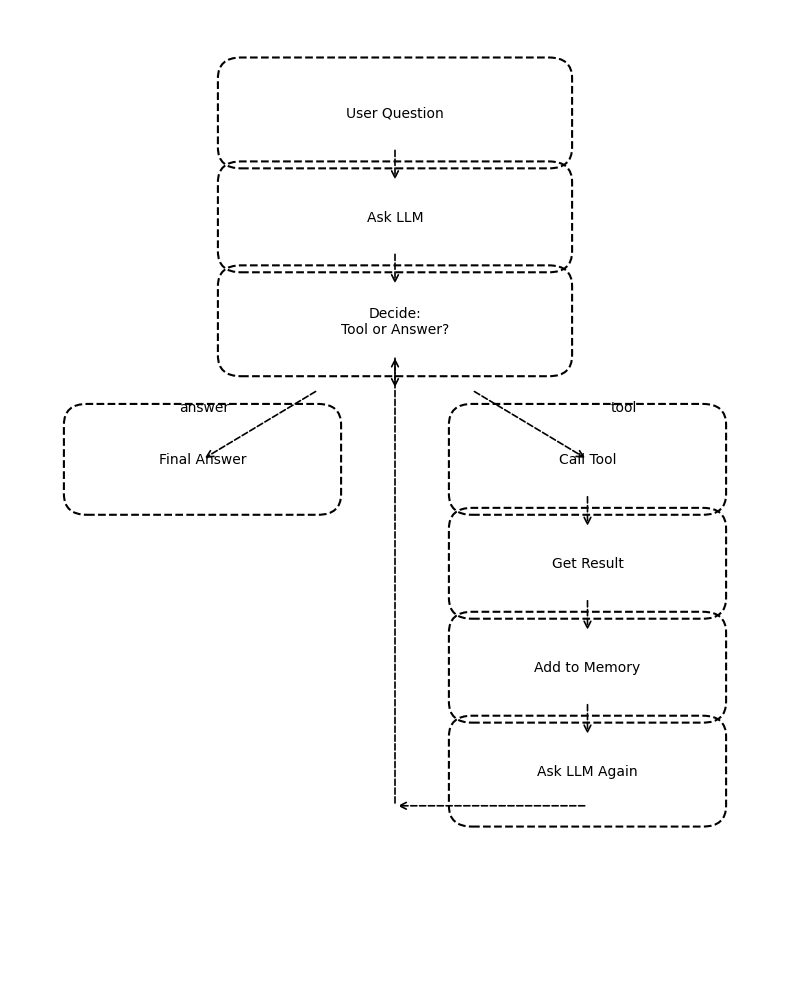

In [48]:
def extract_json(text: str) -> str:
    """
    Extracts a JSON object from LLM output.

    Why needed:
    Small models (like Gemma 1B) often add extra text like:
    "Sure! Here is the JSON:"
    
    This function:
    - Finds the first '{' and last '}'
    - Returns only the JSON part
    """
    match = re.search(r'\{.*\}', text, re.DOTALL)
    return match.group(0) if match else text

In [49]:
import re

def run_react_agent(user_query: str, tools: Dict[str, any], max_steps: int = 5) -> str:
    """
    Runs a simple ReAct-style agent loop.

    Key idea:
    The agent repeatedly:
    1. Asks the LLM what to do next
    2. Executes a tool (if needed)
    3. Feeds the result back to the LLM
    4. Stops when a final answer is produced
    """

    # Strict instructions are VERY important for small models
    # We force the model to output ONLY JSON (no explanations)
    system_instructions = (
        "You are a ReAct agent. You MUST respond with a valid JSON object ONLY.\n"
        "Format for tools: {\"type\": \"tool_call\", \"tool_name\": \"name\", \"tool_args\": {}}\n"
        "Format for finish: {\"type\": \"final_answer\", \"content\": \"answer\"}"
    )
    
    # History = the agent's memory (scratchpad)
    # Stores previous actions and observations
    history = []

    # Loop = multi-step reasoning
    for step in range(max_steps):

        # Convert history into a readable string for the model
        history_str = "\n".join(history)
        
        # Prompt includes:
        # - instructions
        # - user question
        # - previous steps (history)
        prompt = f"{system_instructions}\n\nUser Query: {user_query}\n{history_str}\n\nNext Step (JSON):"

        # Call the LLM
        raw_output = call_llm(prompt)
        
        try:
            # Step 1: Clean output (remove extra text around JSON)
            json_str = extract_json(raw_output)

            # Step 2: Parse JSON into Python dict
            plan = json.loads(json_str)
            
            plan_type = plan.get("type")
            
            # -------------------------
            # CASE 1: Final Answer
            # -------------------------
            if plan_type == "final_answer":
                return plan.get("content", "Error: Missing content in final answer.")

            # -------------------------
            # CASE 2: Tool Call
            # -------------------------
            if plan_type == "tool_call":
                name = plan.get("tool_name")
                args = plan.get("tool_args", {})

                # Check if tool exists
                if name not in tools:
                    observation = f"Error: Tool '{name}' does not exist."
                else:
                    # Execute tool safely
                    try:
                        observation = tools[name].fn(**args)
                    except Exception as e:
                        observation = f"Error executing tool: {str(e)}"

                # Add to history (VERY IMPORTANT)
                # This is how the model "remembers" previous steps
                history.append(f"Action: {name}({args})")
                history.append(f"Observation: {observation}")
            
            # -------------------------
            # CASE 3: Invalid type
            # -------------------------
            else:
                history.append(f"Error: Unknown type '{plan_type}'. Use 'tool_call' or 'final_answer'.")

        except (json.JSONDecodeError, ValueError):
            # If JSON is broken → give feedback to the model
            # This helps it self-correct in the next step
            history.append("Error: Your previous output was not valid JSON. Please try again.")
            continue

    # If loop ends without final answer
    return "Agent exceeded max steps."

In [54]:
run_react_agent("What is square root of (5*5)?", tools)

'4.910175'

What happens if you remove memory?

In [52]:
import json, re

def extract_json(text: str) -> str:
    match = re.search(r'\{.*\}', text, re.DOTALL)
    return match.group(0) if match else text


def run_react_agent_no_history(user_query: str, tools: Dict[str, any], max_steps: int = 5) -> str:
    """
    ReAct agent WITHOUT memory (history).
    
    Each step:
    - LLM sees ONLY the original question
    - No previous actions or observations are provided
    """

    system_instructions = (
        "You are a ReAct agent. You MUST respond with JSON ONLY.\n"
        "Tool: {\"type\":\"tool_call\",\"tool_name\":\"name\",\"tool_args\":{}}\n"
        "Finish: {\"type\":\"final_answer\",\"content\":\"answer\"}"
    )

    for step in range(max_steps):

        # No history here
        prompt = f"{system_instructions}\n\nUser Query: {user_query}\n\nNext Step:"

        raw_output = call_llm(prompt)

        try:
            plan = json.loads(extract_json(raw_output))

            plan_type = plan.get("type")

            # Final answer
            if plan_type == "final_answer":
                return plan.get("content", "Missing final answer")

            # Tool call
            if plan_type == "tool_call":
                name = plan.get("tool_name")
                args = plan.get("tool_args", {})

                if name not in tools:
                    observation = f"Error: Tool '{name}' does not exist."
                else:
                    try:
                        observation = tools[name].fn(**args)
                    except Exception as e:
                        observation = f"Error: {str(e)}"

                # IMPORTANT: observation is NOT saved or reused
                print(f"Step {step+1}: {name} → {observation}")

            else:
                return f"Unknown type: {plan_type}"

        except:
            print("Invalid JSON, retrying...")
            continue

    return "Stopped (no final answer)"

In [53]:
run_react_agent_no_history("What is square root of 5*5?", tools)

'3.5'

The LLM forgets everything after each step
It cannot see previous:
- tool calls
- observations
- reasoning

Add thought field

In [55]:
import re

def run_react_agent_thought(user_query: str, tools: Dict[str, any], max_steps: int = 5) -> str:
    """
    Runs a simple ReAct-style agent loop.

    Key idea:
    The agent repeatedly:
    1. Asks the LLM what to do next
    2. Executes a tool (if needed)
    3. Feeds the result back to the LLM
    4. Stops when a final answer is produced
    """

    # Strict instructions are VERY important for small models
    # We force the model to output ONLY JSON (no explanations)
    system_instructions = (
    "You are a ReAct agent. You MUST respond with a valid JSON object ONLY.\n"
    "Always include a 'thought' field explaining your reasoning.\n"
    "Format for tools: {\"type\": \"tool_call\", \"thought\": \"...\", \"tool_name\": \"name\", \"tool_args\": {}}\n"
    "Format for finish: {\"type\": \"final_answer\", \"thought\": \"...\", \"content\": \"answer\"}"
)
    
    # History = the agent's memory (scratchpad)
    # Stores previous actions and observations
    history = []

    # Loop = multi-step reasoning
    for step in range(max_steps):

        # Convert history into a readable string for the model
        history_str = "\n".join(history)
        
        # Prompt includes:
        # - instructions
        # - user question
        # - previous steps (history)
        prompt = f"{system_instructions}\n\nUser Query: {user_query}\n{history_str}\n\nNext Step (JSON):"

        # Call the LLM
        raw_output = call_llm(prompt)
        
        try:
            # Step 1: Clean output (remove extra text around JSON)
            json_str = extract_json(raw_output)

            # Step 2: Parse JSON into Python dict
            plan = json.loads(json_str)

            plan_type = plan.get("type")
            thought = plan.get("thought", "")
            
            # -------------------------
            # CASE 1: Final Answer
            # -------------------------
            if plan_type == "final_answer":
                return plan.get("content", "Error: Missing content in final answer.")

            # -------------------------
            # CASE 2: Tool Call
            # -------------------------
            if plan_type == "tool_call":
                name = plan.get("tool_name")
                args = plan.get("tool_args", {})

                # Check if tool exists
                if name not in tools:
                    observation = f"Error: Tool '{name}' does not exist."
                else:
                    # Execute tool safely
                    try:
                        observation = tools[name].fn(**args)
                    except Exception as e:
                        observation = f"Error executing tool: {str(e)}"

                # Add to history (VERY IMPORTANT)
                # This is how the model "remembers" previous steps
                history.append(f"Thought: {thought}")
                history.append(f"Action: {name}({args})")
                history.append(f"Observation: {observation}")
            
            # -------------------------
            # CASE 3: Invalid type
            # -------------------------
            else:
                history.append(f"Error: Unknown type '{plan_type}'. Use 'tool_call' or 'final_answer'.")

        except (json.JSONDecodeError, ValueError):
            # If JSON is broken → give feedback to the model
            # This helps it self-correct in the next step
            history.append("Error: Your previous output was not valid JSON. Please try again.")
            continue

    # If loop ends without final answer
    return "Agent exceeded max steps."

In [59]:
run_react_agent_thought("What is square root of (5*5)?", tools)

'The square root of (5*5) is 5.'

Stronger instructions!

In [57]:
import re

def run_react_agent_thought_strong(user_query: str, tools: Dict[str, any], max_steps: int = 5) -> str:
    """
    Runs a simple ReAct-style agent loop.

    Key idea:
    The agent repeatedly:
    1. Asks the LLM what to do next
    2. Executes a tool (if needed)
    3. Feeds the result back to the LLM
    4. Stops when a final answer is produced
    """

    # Strict instructions are VERY important for small models
    # We force the model to output ONLY JSON (no explanations)
    system_instructions = (
    "You are a ReAct agent. You MUST respond with a valid JSON object ONLY.\n"
    "Always include a 'thought' field explaining your reasoning.\n"
    "\n"
    "Behavior rules:\n"
    "1. Solve the problem step by step.\n"
    "2. If the problem requires external information or computation, use a tool.\n"
    "3. Use previous observations to decide the next step.\n"
    "4. Do not repeat the same action with the same arguments unless necessary.\n"
    "5. Do not give a final answer until the problem is fully solved.\n"
    "6. If a tool returns an error, analyze the error and try a better next step.\n"
    "7. If the answer can be given directly without a tool, return a final_answer.\n"
    "\n"
    "Format for tools: "
    "{\"type\": \"tool_call\", \"thought\": \"...\", \"tool_name\": \"name\", \"tool_args\": {}}\n"
    "Format for finish: "
    "{\"type\": \"final_answer\", \"thought\": \"...\", \"content\": \"answer\"}"
    )
    
    # History = the agent's memory (scratchpad)
    # Stores previous actions and observations
    history = []

    # Loop = multi-step reasoning
    for step in range(max_steps):

        # Convert history into a readable string for the model
        history_str = "\n".join(history)
        
        # Prompt includes:
        # - instructions
        # - user question
        # - previous steps (history)
        prompt = f"{system_instructions}\n\nUser Query: {user_query}\n{history_str}\n\nNext Step (JSON):"

        # Call the LLM
        raw_output = call_llm(prompt)
        
        try:
            # Step 1: Clean output (remove extra text around JSON)
            json_str = extract_json(raw_output)

            # Step 2: Parse JSON into Python dict
            plan = json.loads(json_str)

            plan_type = plan.get("type")
            thought = plan.get("thought", "")
            
            # -------------------------
            # CASE 1: Final Answer
            # -------------------------
            if plan_type == "final_answer":
                return plan.get("content", "Error: Missing content in final answer.")

            # -------------------------
            # CASE 2: Tool Call
            # -------------------------
            if plan_type == "tool_call":
                name = plan.get("tool_name")
                args = plan.get("tool_args", {})

                # Check if tool exists
                if name not in tools:
                    observation = f"Error: Tool '{name}' does not exist."
                else:
                    # Execute tool safely
                    try:
                        observation = tools[name].fn(**args)
                    except Exception as e:
                        observation = f"Error executing tool: {str(e)}"

                # Add to history (VERY IMPORTANT)
                # This is how the model "remembers" previous steps
                history.append(f"Thought: {thought}")
                history.append(f"Action: {name}({args})")
                history.append(f"Observation: {observation}")
            
            # -------------------------
            # CASE 3: Invalid type
            # -------------------------
            else:
                history.append(f"Error: Unknown type '{plan_type}'. Use 'tool_call' or 'final_answer'.")

        except (json.JSONDecodeError, ValueError):
            # If JSON is broken → give feedback to the model
            # This helps it self-correct in the next step
            history.append("Error: Your previous output was not valid JSON. Please try again.")
            continue

    # If loop ends without final answer
    return "Agent exceeded max steps."

In [58]:
run_react_agent_thought_strong("What is square root of (5*5)?", tools)

'The square root of 5*5 is 5. Finally, the answer is 5.'